In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.ndimage import uniform_filter1d
import PKA_Sleep as PKA
import os
import pandas as pd
PKA.Graphing_Utils.make_bigandbold()

In [6]:
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 200
experimental_sensor = 'FLIM-mAKAR'
sleep_states = False
microarousals = True
seperate_acqs = False
emp_lifetime = False
gather_timestamps = False
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
experiment_names = ['ltFLiPAKARmemEEGEMG0094']
mouse_names = ['4775']

df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [os.path.join(parent_data_directory, e) for e in experiment_names]
baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in experiment_names]]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 3, specific_acqs = False, 
                                          pull_baseline = True, baseline_idxs = baseline_idxs)
   
FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                      exclude_acqs = excluded_acqs)

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_28193/838521833.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values))


You are excluding the first 3 acquisitions of this experiment.
You didn't put any filter values


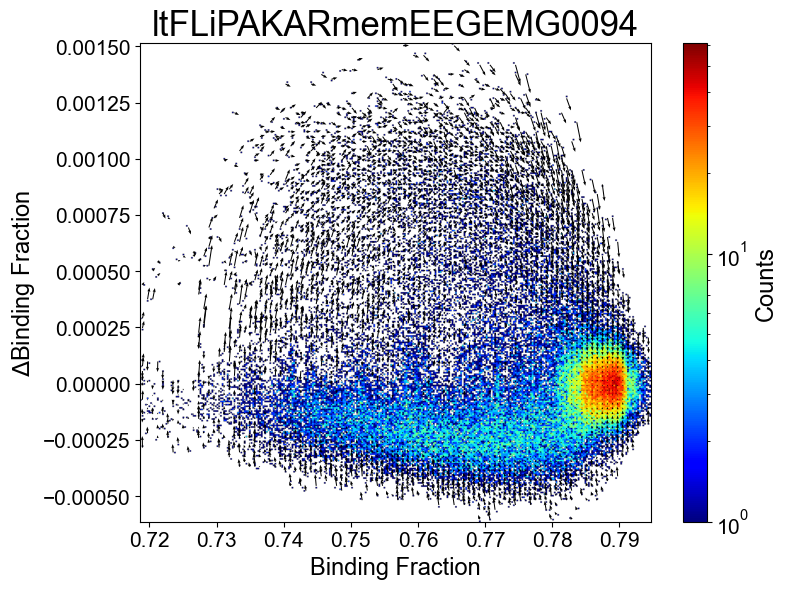

In [7]:
fig_ext ='.svg'
for b, FLP_exp in zip(FLP_classes_dict['Experiment Names'], FLP_classes_dict['Experiment Classes']):
    fig, ax = plt.subplots(figsize = [8,6])
    fig, ax = PKA.PhosphoPlot(FLP_exp.Lifetime, fig, ax, b, filterbin_width = 40, scale = 8, alpha = 1, headwidth=3, 
        headlength=4, headaxislength=3.5, width = 0.002)
    fig.tight_layout()
    fig.savefig(os.path.join(FLP_exp.rawdatdir, 'PhosPhoplot' + b + fig_ext))